In [1]:
import random
import operator
from typing import TypedDict, List, Literal, Annotated
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    name: str
    numbers: Annotated[List[int], operator.add]
    counter: Annotated[int, operator.add]

In [8]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to a person"""

    state["name"] = f"Hello, {state['name']}"
    state["counter"] = 0
    state["numbers"] = []

    return state
def random_node(state: AgentState) -> dict:
    """Generates a random number from 0 to 50"""

    print(state)

    new_num = random.randint(0, 50)

    return { "numbers": [new_num], "counter": 1 }

def should_continue(state: AgentState) -> Literal["continue", "break"]:
    """Decide if the loop should continue"""

    return "continue" if state["counter"] < 5 else "break"

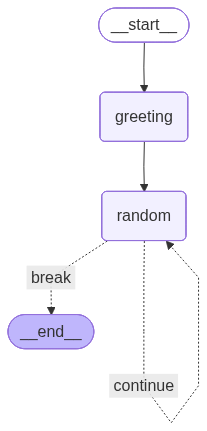

In [9]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random", # Source node
    should_continue, # Action
    {
        "continue": "random",
        "break": END
    }
)

app = graph.compile()

app

In [10]:
state = AgentState(name="youssef")
app.invoke(state)

{'name': 'Hello, youssef', 'numbers': [], 'counter': 0}
{'name': 'Hello, youssef', 'numbers': [1], 'counter': 1}
{'name': 'Hello, youssef', 'numbers': [1, 1], 'counter': 2}
{'name': 'Hello, youssef', 'numbers': [1, 1, 41], 'counter': 3}
{'name': 'Hello, youssef', 'numbers': [1, 1, 41, 16], 'counter': 4}


{'name': 'Hello, youssef', 'numbers': [1, 1, 41, 16, 19], 'counter': 5}